# Points across minutes-bands — characterising the 60-minute mark *(population)*

*Read-only informative artifact. Sits in the **Descriptive** tier: it describes
how the target Y (`total_points`) sits across the minutes axis — the bands × Y
relational read — so a human can see whether the 60-minute mark separates two
scoring regimes. It imposes no gate, runs no PROCEED/STOP verdict, and makes no
causal claim.*

## Questions a manager asks about the 60-minute mark

- **Does the 60-minute mark actually separate two regimes** — a cameo regime
  where points barely move, and a genuine-starter regime where scoring lifts —
  or is it an arbitrary line drawn through one continuous landscape?
- **What would a 60-minute filter include and exclude?** Which appearances does
  it keep as "genuine outings" and which cameos does it discard?
- **Is 60 a sensible boundary or an arbitrary one?** Other foundation layers
  use a `minutes > 0` participation filter and explicitly defer the 60-minute
  question to here — this notebook is where it gets looked at.

Everything below is **season-pooled**. The population is the **wider featured
base** (all rows with `minutes > 0`) examined across the **full minutes axis**
— because the boundary question is about what happens *along* that axis, not
within one slice of it. The minutes bands themselves are established in
`minutes_distribution.ipynb`.

## Setup

Load the mart, restrict to the **whole season** (GW 1 to the latest completed
GW), and take the **wider featured base**: all rows with `minutes > 0`. We then
examine `total_points` and scoring rates **across the full minutes axis**, with
the 60-minute mark drawn in for reference.

The population is the **participation** base (`minutes > 0` — the player
featured). `minutes` can be NULL on blank-gameweek rows; `minutes > 0` excludes
those naturally. We deliberately keep the **whole** featured range — cameos
included — because the entire point of this notebook is to look at the boundary
*in situ*, not to apply it. No 60-minute filter is imposed anywhere below.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.distribution import (
    compute_distribution_stats,
    compare_cohorts,
)

try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

# Descriptive characterisation uses the WHOLE season: GW 1 to the latest
# completed GW. No early-GW lower bound (that was a predictive-evaluation
# choice in the older EDA-1 record, not relevant here).
STUDY_GW_MIN = 1
STUDY_GW_MAX = _result.data_cutoff_gw

POSITIONS = ["GK", "DEF", "MID", "FWD"]
mart = _result.mart

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.3f}".format)

# WIDER featured base for the boundary question: all rows with minutes > 0,
# examined across the FULL minutes axis. No 60-minute filter is imposed.
# DGW excluded for now (is_dgw == False) so the axis is single-fixture -- no
# ~180-minute doubled rows confounding the binned mean.
df = mart[mart["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["is_dgw"] == False].copy()

cohorts = {pos: df[df.position == pos] for pos in POSITIONS}

print(f"Study range: GW {STUDY_GW_MIN} - GW {STUDY_GW_MAX} (whole season, from mart data_cutoff_gw)")
print(f"Population: minutes > 0, DGW excluded (wider featured base, full minutes axis), n = {len(df):,} player-gameweeks")
for pos in POSITIONS:
    print(f"  {pos}: {len(cohorts[pos]):>6,}")

Study range: GW 1 - GW 38 (whole season, from mart data_cutoff_gw)
Population: minutes > 0, DGW excluded (wider featured base, full minutes axis), n = 11,190 player-gameweeks
  GK:    747
  DEF:  3,845
  MID:  5,208
  FWD:  1,390


## (a) Points by minutes band — typical (median) and ceiling (p90)

**What we measure** — pooled `total_points` per minutes band (`1-29 / 30-59 /
60+`), summarised by **median** (the typical return / floor) and **p90** (the
ceiling / upside) — two bars per band. Mean is not used: on zero-inflated,
right-skewed points it sits in a gap and describes no real return.

**What it means** — the regime read in one picture. Below 60 both bars are
pinned at the appearance point (≈ 1): no typical return *and* no upside. At
`60+` both jump (median 3, p90 8). Both sub-60 bands being flat is the evidence
that the step is **at 60**, not a gradual ramp — and that the change is a floor
*and* a ceiling effect, not just a shift in the average.

**What it doesn't mean** — **not a causal claim.** Exposure is confounded with
player quality (better players both start and score), so the lift is *who plays
long*, not the *effect of playing long*. Pooled, season-pooled, DGW excluded.
Per-position detail is in the (b) table.

**Guiding question (directive)** — *Establish whether the typical return and the
upside step up at 60, or rise gradually.*

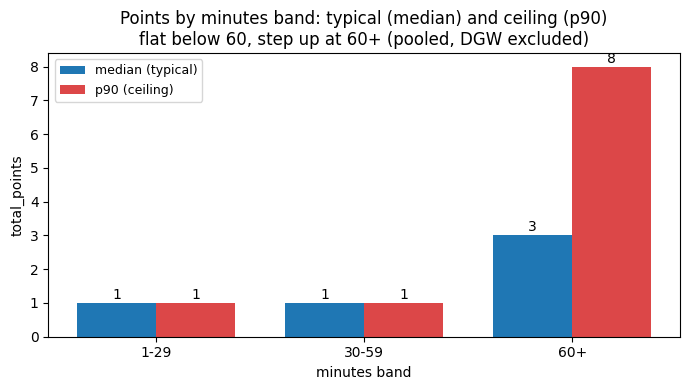

In [2]:
# Simple pooled view: median (typical return / floor) and p90 (ceiling / upside)
# of total_points in each minutes band. Two bars per band -- the whole story:
# below 60 both are pinned at the appearance point (~1); at 60+ both jump.
# Mean is not used (zero-inflated, right-skewed -> describes no real return).
# DESCRIPTIVE, confounded with player quality (see "What it doesn't mean").
BANDS = ["1-29", "30-59", "60+"]

def _band(mn):
    return "1-29" if mn < 30 else "30-59" if mn < 60 else "60+"

_p = df.dropna(subset=["minutes", "total_points"]).copy()
_p["band"] = _p["minutes"].astype(int).map(_band)
med = _p.groupby("band")["total_points"].median().reindex(BANDS)
p90 = _p.groupby("band")["total_points"].quantile(0.90).reindex(BANDS)

x = np.arange(len(BANDS))
w = 0.38
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w / 2, med.to_numpy(), w, color="#1f77b4", label="median (typical)")
ax.bar(x + w / 2, p90.to_numpy(), w, color="#d62728", alpha=0.85, label="p90 (ceiling)")
for xi, m, p in zip(x, med.to_numpy(), p90.to_numpy()):
    ax.text(xi - w / 2, m + 0.12, f"{m:.0f}", ha="center", fontsize=10)
    ax.text(xi + w / 2, p + 0.12, f"{p:.0f}", ha="center", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(BANDS)
ax.set_xlabel("minutes band")
ax.set_ylabel("total_points")
ax.set_title("Points by minutes band: typical (median) and ceiling (p90)\n"
             "flat below 60, step up at 60+ (pooled, DGW excluded)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## (b) Scoring quantiles and blank rate in minutes bands, by position

**What we measure** — within three **minutes bands** (`1-29`, `30-59`, `60+`),
per position, the **blank rate** (the floor, `P(total_points == 0)`), the
**median** (typical return), the **IQR** (p25-p75, the middle chunk) and **p90**
(the ceiling). The count `n` per cell is shown so thin bands are visible. Bands
collapse at `60+` because FPL's rules do not distinguish `60-89` from `90` (same
appearance / clean-sheet regime). **Mean is omitted** — see (a).

**What it means** — the exact numbers behind the (a) fan, at the three decision
bands. The signature of a real boundary at 60 is all of them moving together:
blank rate **falls**, median **rises**, and the upper tail (p75 / p90)
**fattens** as appearances cross into `60+`. Below 60 the distribution is
essentially pinned at the appearance point (median *and* p90 both ≈ 1), so the
*upside itself* only opens up at 60+ — a ceiling effect, not just a floor one.
This is the "what would a 60-minute filter keep vs discard" question, made
concrete.

**What it doesn't mean** — same confound as (a): the lift across the boundary is
**not causal**. Players who reach 60+ minutes are disproportionately the better,
nailed starters, so the band differences reflect *player composition*, not the
*effect of minutes*. The bands are **season-pooled** with **DGW excluded**. The
`30-59` band in particular mixes half-time substitutions, early injuries and
tactical hooks — its higher blank rate is partly mechanical (a player subbed at
half-time had less time to score), not a performance verdict. **No band is
excluded or gated.**

**Guiding question (directive)** — *Establish what a 60-minute filter would
include versus discard — quantify how the blank-rate floor, the median and the
p90 ceiling move across the mark.*

In [3]:
# Y distribution per (position, minutes band): the floor (blank_% = P(points=0)),
# the typical return (median), the middle chunk (p25-p75) and the ceiling (p90).
# Mean is deliberately omitted -- on zero-inflated, right-skewed points it sits in
# a gap and describes no real return. DESCRIPTIVE only; cross-band lift is
# confounded with player quality and is NOT causal. Bands collapse at 60+.
BANDS = ["1-29", "30-59", "60+"]

def _band(mn):
    if mn < 30:
        return "1-29"
    if mn < 60:
        return "30-59"
    return "60+"

work = df.dropna(subset=["minutes", "total_points"]).copy()
work["band"] = work["minutes"].astype(int).map(_band)

rows = []
for pos in POSITIONS:
    c = work[work.position == pos]
    for b in BANDS:
        y = c.loc[c["band"] == b, "total_points"].astype(float)
        rows.append({
            "position": pos, "band": b, "n": len(y),
            "blank_%": round((y == 0).mean() * 100, 1) if len(y) else np.nan,
            "median": round(y.median(), 1) if len(y) else np.nan,
            "p25": round(y.quantile(0.25), 1) if len(y) else np.nan,
            "p75": round(y.quantile(0.75), 1) if len(y) else np.nan,
            "p90": round(y.quantile(0.90), 1) if len(y) else np.nan,
        })
band_scoring = pd.DataFrame(rows)
band_scoring["band"] = pd.Categorical(band_scoring["band"], categories=BANDS, ordered=True)
band_scoring["position"] = pd.Categorical(band_scoring["position"], categories=POSITIONS, ordered=True)
band_scoring = band_scoring.sort_values(["position", "band"]).reset_index(drop=True)
display(band_scoring)

,position,band,n,blank_%,median,p25,p75,p90
0,GK,1-29,4,25.000,0.500,-0.800,1.000,1.000
1,GK,30-59,6,0.000,1.000,1.000,1.000,1.500
2,GK,60+,737,2.000,2.000,2.000,6.000,7.000
3,DEF,1-29,618,8.600,1.000,1.000,1.000,1.000
4,DEF,30-59,283,27.200,1.000,0.000,1.000,1.000
5,DEF,60+,2944,6.200,2.000,1.000,6.000,8.000
6,MID,1-29,1427,5.300,1.000,1.000,1.000,1.000
7,MID,30-59,597,9.200,1.000,1.000,1.000,1.000
8,MID,60+,3184,0.300,3.000,2.000,5.000,9.000
9,FWD,1-29,504,4.000,1.000,1.000,1.000,4.000


In [4]:
# Pooled-across-positions view of the same bands: floor (blank_%), typical
# (median), middle chunk (p25-p75) and ceiling (p90) across the 60-minute mark.
rows = []
for b in BANDS:
    y = work.loc[work["band"] == b, "total_points"].astype(float)
    rows.append({
        "band": b, "n": len(y),
        "blank_%": round((y == 0).mean() * 100, 1),
        "median": round(y.median(), 1),
        "p25": round(y.quantile(0.25), 1),
        "p75": round(y.quantile(0.75), 1),
        "p90": round(y.quantile(0.90), 1),
    })
band_scoring_pooled = pd.DataFrame(rows)
display(band_scoring_pooled)

,band,n,blank_%,median,p25,p75,p90
0,1-29,2553,5.900,1.000,1.000,1.000,1.000
1,30-59,1030,13.400,1.000,1.000,1.000,1.000
2,60+,7607,2.800,3.000,2.000,5.000,8.000


## What the 60-minute boundary looks like

Plain-language summary of the descriptive picture (not a verdict, not a gate,
not a causal claim):

- **There is a clear step at 60, not a smooth ramp.** Below 60 the points
  distribution is essentially pinned at the appearance point — pooled **median 1
  with p25 = p75 = p90 = 1**: almost no spread and no upside. At `60+` it opens
  up: **median 3, IQR 2–5, p90 8**. The fan shows the jump sitting on the 60
  edge, with a further mild climb *within* 60+ (60-75 median 2 → 75-90 median 3)
  — a sharp step, then a gentle rise.
- **The change is a floor *and* a ceiling effect.** The blank-rate floor
  collapses (pooled **13.4%** at `30-59` → **2.8%** at `60+`), *and* the ceiling
  appears: p90 goes from **1** below 60 (even the 90th percentile is just the
  appearance point) to **8** at 60+. Hauls essentially only exist past 60.
- **The `30-59` band carries its own mechanical story** — it has the *highest*
  blank rate (13.4%), inflated by half-time hooks and early injuries (a player
  subbed at the break had less time to score), so it should not be read as a
  pure performance verdict.

**Crucial framing.** This notebook **characterises** the 60-minute mark; it does
**not** impose it as a gate, and it makes **no causal claim**. Exposure is
confounded with player quality — better players both start and score — so any
lift across the boundary describes *who plays long*, not the *effect of playing
long*. All figures are **whole-season**, season-pooled, with **DGW excluded**
(`is_dgw == False`); per-fixture DGW treatment is deferred to the `fixture/`
layer.

**Pointer.** Whether the population choice (`minutes > 0` vs `minutes >= 60`)
changes the signal–points association is *described* separately in
`scope_sensitivity.ipynb`; *explaining* any such change is a Diagnostic-tier
analysis, deferred.